##### 0. Preamble

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import Laborer, Government
import time
import warnings

from scipy.optimize import minimize_scalar
from scipy.optimize import root_scalar
from types import SimpleNamespace
from mpl_toolkits.mplot3d import Axes3D
from collections import Counter

# Model Project

In the below project, I perform three modelling excercises; firstly, a model for the *labor supply*, then one modelling a *public good* and, thereafter, the *top tax*, before I extend the analysis with an additional Lorenz-curve for different values of $\sigma_p^2$:

## 1. Labor supply

With post tax income defined in (1) and the workers utility function in (2), first, I consider the optimization problem in (3). Specifically, I consider the reformulation in (4) (and the derived FOC in (5)), where labour input, $\ell_i$, is maximized given productivity, $p_i$. 

### 1.1.1 Plotting the utility function

Let me first specify the expression for $c_i$:

\begin{align*}
    c_i=y_i=(1-\tau)w p_i \ell_i-\zeta \quad (\equiv c_i(p_i,\ell_i))
\end{align*}

Using $c_i(p_i,\ell_i)$ allows me to plot $U(p_i,c_i,\ell_i)$ in the $(\ell_i,U)$-plane

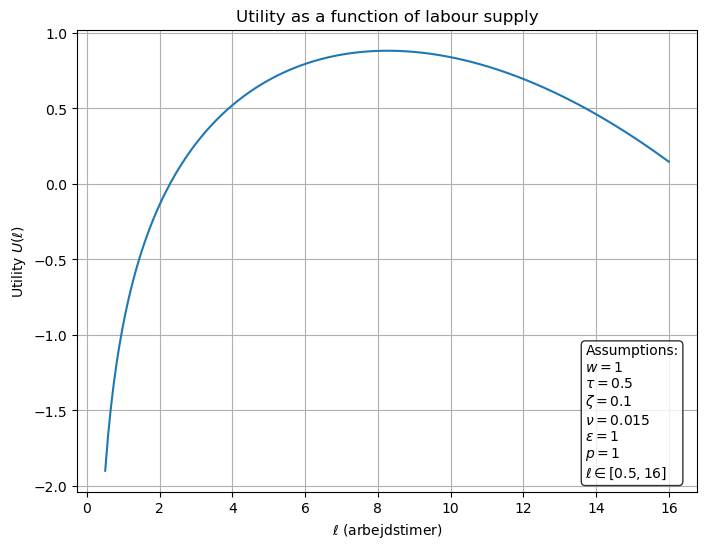

In [2]:
# 1. get model and parameters
model = Laborer.labourer_class()
par = model.par

# 2. define interval
ell_min = 0.5
ell_max = par.ell_max

# 3. get values of ell and U
ell_grid = np.linspace(ell_min, ell_max, 200)
U = model.utility(ell_grid)

# 4. plot                                  
# 4.1 set up plot
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(ell_grid, U)
ax.set_xlabel(r'$\ell$ (arbejdstimer)')
ax.set_ylabel('Utility $U(\ell)$')
ax.set_title('Utility as a function of labour supply')
ax.grid(True)

# 4.2 define key assumptions
assumptions = (
    r"Assumptions:" "\n"
    rf"$w = {par.w}$" "\n"
    rf"$\tau = {par.tau}$" "\n"
    rf"$\zeta = {par.zeta}$" "\n"
    rf"$\nu = {par.nu}$" "\n"
    rf"$\varepsilon = {par.epsilon}$" "\n"
    rf"$p = {par.p}$" "\n"
    rf"$\ell\in[0.5,16]$"
)
ax.text(
    0.82, 0.32, assumptions,
    transform=ax.transAxes,   
    va='top', ha='left',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='black')
)

plt.show()

> **Partial conclusion:** A visual judgement suggets that the utility maximizing amount of labor is around $8$ hours, given the calibration.
>
> I notice that the function is concave in $\ell$, which aligns with the intuition that there is an interior solution to the prefered amount of hours worked.

### 1.1.2 Plotting the *FOC*

In (5), the FOC is given by the function $\varphi(p_i,c_i,\ell_i)$, through the same subsitution as before this can be reduced to $\varphi(p_i,\ell_i)$, which is a function of one variable given $p_i=1$.

I model this into `Laborer.py` and call the function like before, I reuse the defined linspace for $\ell$:

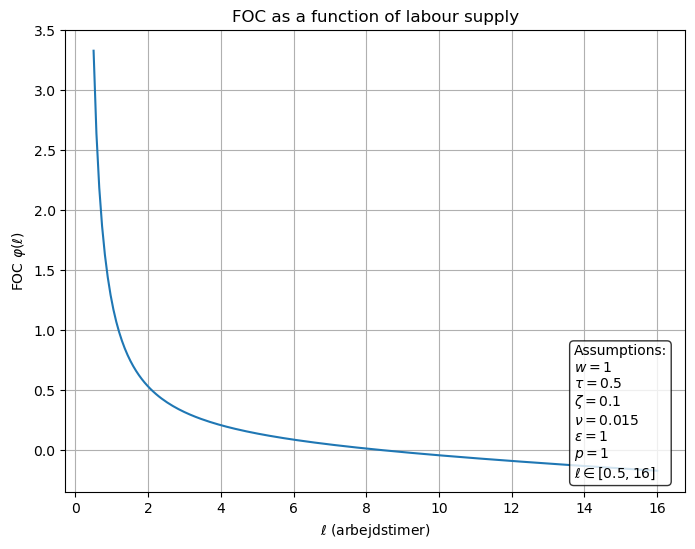

In [3]:
# 1. get FOC-values
varphi = model.FOC(ell_grid)

# 2. plot                                   
# 2.1 set up plot
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(ell_grid, varphi)
ax.set_xlabel(r'$\ell$ (arbejdstimer)')
ax.set_ylabel(r'FOC $\varphi(\ell)$')
ax.set_title('FOC as a function of labour supply')
ax.grid(True)

# 2.2 define key assumptions
assumptions = (
    r"Assumptions:" "\n"
    rf"$w = {par.w}$" "\n"
    rf"$\tau = {par.tau}$" "\n"
    rf"$\zeta = {par.zeta}$" "\n"
    rf"$\nu = {par.nu}$" "\n"
    rf"$\varepsilon = {par.epsilon}$" "\n"
    rf"$p = {par.p}$" "\n"
    rf"$\ell\in[0.5,16]$"
)
ax.text(
    0.82, 0.32, assumptions,
    transform=ax.transAxes,   
    va='top', ha='left',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='black')
)

plt.show()

> **Partial conclusion:** *FOC* is declining exponentially in the number of hours worked, meaning that each extra hour worked yields a smaller marginal utility than the previous.
>
> This feature is the cause of the interior solution as seen before.

### 1.1.3 Optimal hours worked as a function of productivity (Numerical optimization)

Given productivity, $p_i=1$, I derive the optimal number of hours worked, $\ell^\star(p_i)$ using a numerical optimizer. Specifically, I solve (4) for $V(1)$ within the space $\ell_i\in(\underline{\ell}_i,16)$. 

As (4) is essentially optimizing $U(1,c_i(1,\ell_i),\ell_i)$, which I ahve already defined in `Labourer.py`, this will become the basis for my optimization:

In [4]:
# 1. call solution from module (see #5 in Labourer.py)
model.numerical_optimization()


=== Numerical solution for optimal labour supply ===

Price (p)        : 1.000
Wage (w)         : 1.000
Tax rate (tau)   : 0.500
Transfer (zeta)  : 0.100
ell bounds       : [0.200, 16.000]
----------------------------------------------------
Optimal hours ell* : 8.265578
Utility U(ell*)    : 0.882060



> **Partial conclusion:** As per the visual analysis, the optimal amount of hours worked is just above $8$, which is also the standard in DK.

### 1.1.4 Root-finder

I compute the solution to the same problem, this time using a root-finder to solve the *FOC*:

In [5]:
# 1. call solution from module (see #6 in Labourer.py)
model.root_finder()


=== Root-finder solution for optimal labour supply ===

Price (p)        : 1.000
Wage (w)         : 1.000
Tax rate (tau)   : 0.500
Transfer (zeta)  : 0.100
ell bounds       : [0.200, 16.000]
----------------------------------------------------
Optimal hours ell* : 8.265578
Utility U(ell*)    : 0.882060



> **Partial conclusion:** All the way doen to six decimals, the who solutions are equivalent.

### 1.1.5 Comparison

As mentioned, the two methods yield the same result, the difference is simply in their solving-approach. In the below, I test the solution speed:

In [6]:
# 1. find time for numerical optimizer
t0 = time.perf_counter()
model.numerical_optimization(verbose=False)  
t1 = time.perf_counter()
elapsed_num = t1 - t0

# 2. same for the root-finder
t0 = time.perf_counter()
model.root_finder(verbose=False)  
t1 = time.perf_counter()
elapsed_root = t1 - t0

# 3. print
print(f"Elapsed time (numerical optimization): {elapsed_num*1000:.3f} ms ({elapsed_num:.3f} seconds.)")
print(f"Elapsed time (root finder): {elapsed_root*1000:.3f} ms ({elapsed_root:.3f} seconds.)")

Elapsed time (numerical optimization): 0.423 ms (0.000 seconds.)
Elapsed time (root finder): 0.291 ms (0.000 seconds.)


> **Partial conclusion:** It is evident that the root finder is a lot quicker, it takes less almost just 1/3 of the numerical solving time.
>
> This might become essential as the project increases in size, but does not matter at this stage.

### 1.1.6 Plot

At last, I combine my findings in the below plot:

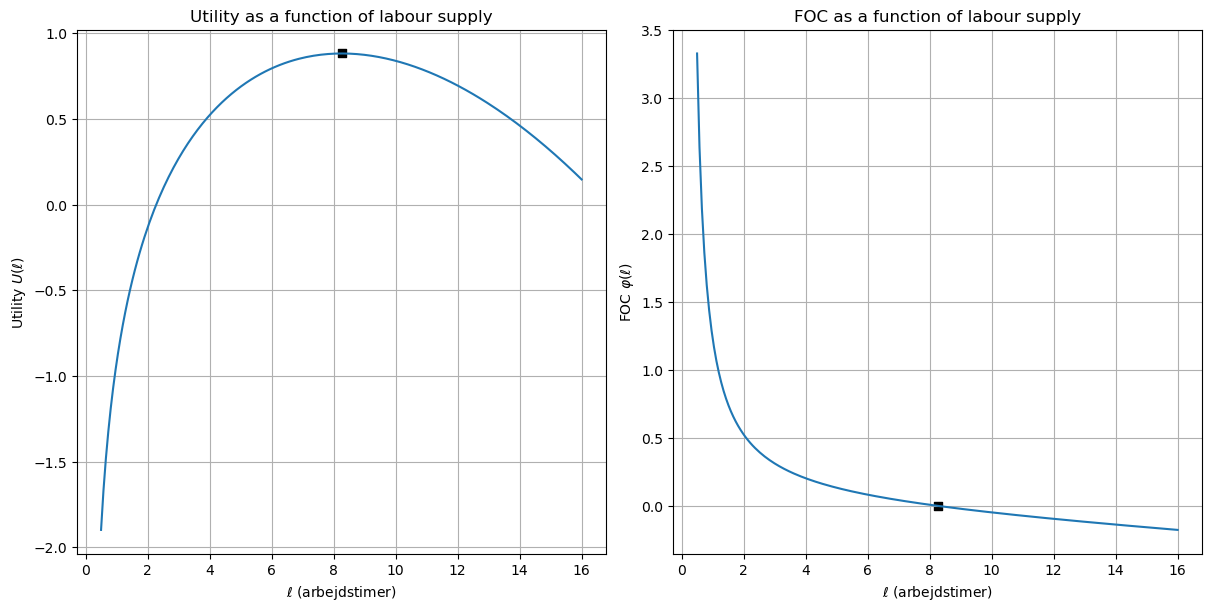

In [7]:
sol = model.sol

# 1. initiate figure
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), sharex=True, constrained_layout=True)

# 2.1 plot utility level
ax[0].plot(ell_grid, U)
ax[0].set_xlabel(r'$\ell$ (arbejdstimer)')
ax[0].set_ylabel('Utility $U(\ell)$')
ax[0].set_title('Utility as a function of labour supply')
ax[0].grid(True)

# 2.2 plot FOC
ax[1].plot(ell_grid, varphi)
ax[1].set_xlabel(r'$\ell$ (arbejdstimer)')
ax[1].set_ylabel(r'FOC $\varphi(\ell)$')
ax[1].set_title('FOC as a function of labour supply')
ax[1].grid(True)

# 2.2 add solution
ax[0].scatter(sol.ell_star,sol.U_star,marker='s',color='black',label='Optimum')
ax[1].scatter(sol.ell_star,sol.FOC_at_root,marker='s',color='black',label='Optimum')

> **Partial conclusion:** Here the earlier plots are repeated; the fact that the value of $\varphi(\ell)$ is zero at the optimum confirms that the solution is correct.

### 1.1.7 Extention

At last I'm asked to repeat the analysis for $\epsilon=\{0.75,0.5\}$, changing as little code as possible. My adaptation just redefines $\epsilon$ globally before running the functions. Then computing multiple scenarios will become possible within a loop:

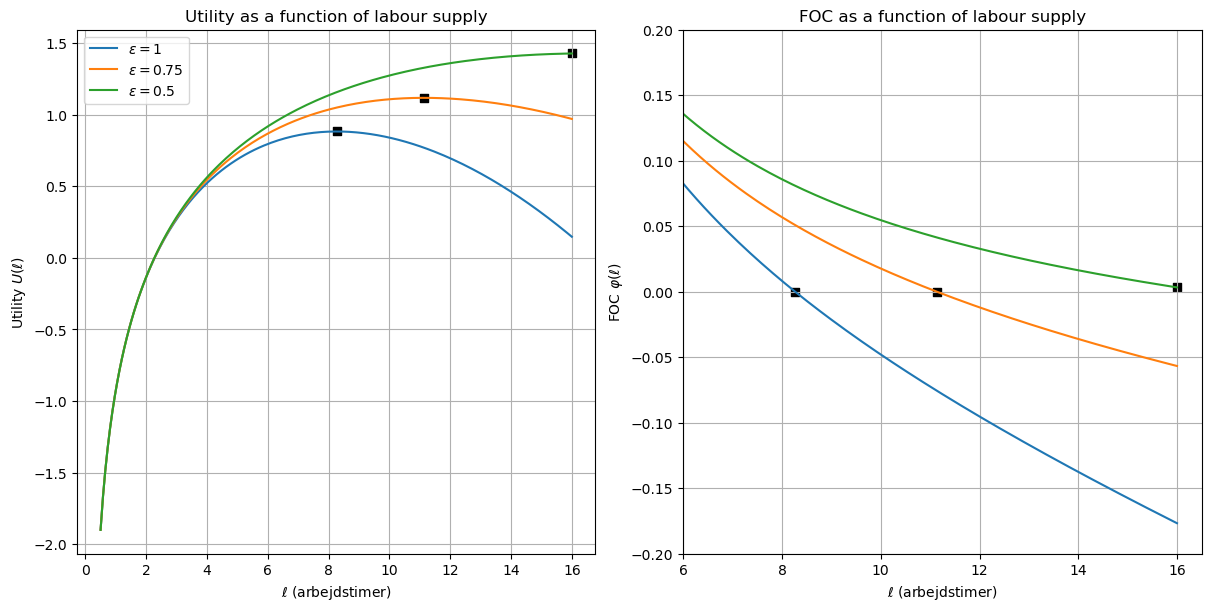

In [8]:
# 1. initiate figure
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), constrained_layout=True)

# 2. set up subplots
ax[0].set_xlabel(r'$\ell$ (arbejdstimer)')
ax[0].set_ylabel('Utility $U(\ell)$')
ax[0].set_title('Utility as a function of labour supply')
ax[0].grid(True)

# 2.2 plot FOC
ax[1].set_xlabel(r'$\ell$ (arbejdstimer)')
ax[1].set_ylabel(r'FOC $\varphi(\ell)$')
ax[1].set_title('FOC as a function of labour supply')
ax[1].grid(True)
ax[1].set_ylim(-0.2,0.2)
ax[1].set_xlim(6,16.5)

# 3. loop to get values
for eps in [1, 0.75, 0.5]:
    
    # 3.1 run root-finder with changes
    model = Laborer.labourer_class()
    sol = model.sol
    par = model.par
    par.epsilon = eps
    model.root_finder(verbose=False)
    
    # 3.2 get output
    U = model.utility(ell_grid)
    varphi = model.FOC(ell_grid)
    
    # 3.3 plot lines and optimi
    ax[0].plot(ell_grid, U, label=rf'$\epsilon = {eps}$')
    ax[1].plot(ell_grid, varphi)
    
    ax[0].scatter(sol.ell_star_root,sol.U_star_root,marker='s',color='black')
    ax[1].scatter(sol.ell_star_root,sol.FOC_at_root,marker='s',color='black')

    ax[0].legend()

> **Partial conclusion:** As epsilon decreases the number of hours worked in optimum increases and the same does the utility level. This is beacuse epsilon governs the curvature of the disutility of labour.
>
> In the left panel it is evident that $\epsilon=0.5$ leads to a corner solution as the *FOC* is slightly above zero. Thus, this is not the global optimum, the worker hits the maximum number allowed.

### 1.2.1-2 Optimal hours work for different prices

Again looping over a vector of $p_i$ values and redefining globally each time, allows for an implementation without changing anything in `Laborer.py`:

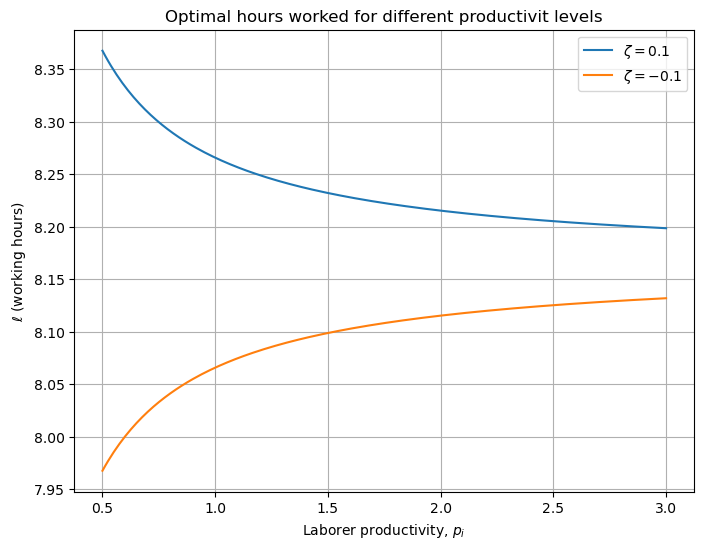

In [9]:
# 1. define p-grid
p_grid = np.linspace(0.5, 3, 200)
zetas = [0.1, -0.1]

# 2. set up figure
fig, ax = plt.subplots(figsize=(8,6))
ax.set_ylabel(r'$\ell$ (working hours)')
ax.set_xlabel(r'Laborer productivity, $p_i$')
ax.set_title('Optimal hours worked for different productivit levels')
ax.grid(True)

# 3. drouple loop both zeta and productivity
for zeta_val in zetas:
    ell_sol_grid = []

    for p_val in p_grid:
        
        # 3.1 run root-finder with changes
        model = Laborer.labourer_class()
        sol = model.sol
        par = model.par
        par.p = p_val
        par.zeta = zeta_val
        
        model.root_finder(verbose=False)
        sol = model.sol
        
        # 3.2 get solutions
        ell_val = sol.ell_star_root
        ell_sol_grid.append(ell_val)
        
    # 3.3 plot
    ax.plot(p_grid, ell_sol_grid, label=f'$\zeta = {zeta_val}$')
    ax.legend()

> **Partial conclusion:** We see that hours worked is decreasing in the labor productivity exponentially when $\zeta>0$, while the opposite is the case when $\zeta<0$.
> 
> The intuition is that a positive lump-sum tax rate increases the amount of hours to be worked for each level of compensation, while a subsidy has the opposite effect. 
>
> Interestingly, the effect is dissapearing as the worker productivity increases, seemingly converging to the same value.

## 2. Public good

### 2.1.1-3 Tax revenue and social welfare

First I compute functions $T(\tau,\zeta)$ and the SWF as $SWF(\tau,\zeta)$ as defined in (7) and (9) respectively. 

For $\log p_i\sim\mathcal{N}(-0.5\sigma_p^2,\sigma_p^2)$ is use the provided setup for the random number generator. Having done this, I plot the total tax income (government spending) and the social welfare function:

/Users/linuslindquist/Desktop/PfE/projects-2025-ll/02_modelproject/Government.py:97: RuntimeWarning: invalid value encountered in scalar power
  SWF_val = par.chi * T**par.eta + np.sum(U_vec)
/var/folders/t6/3c29w60n57n_vr9ftbb88pdr0000gn/T/ipykernel_89854/373971384.py:44: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[1].axvspan(0.02, 0.1, alpha=0.15, color='grey', edgecolor='none')


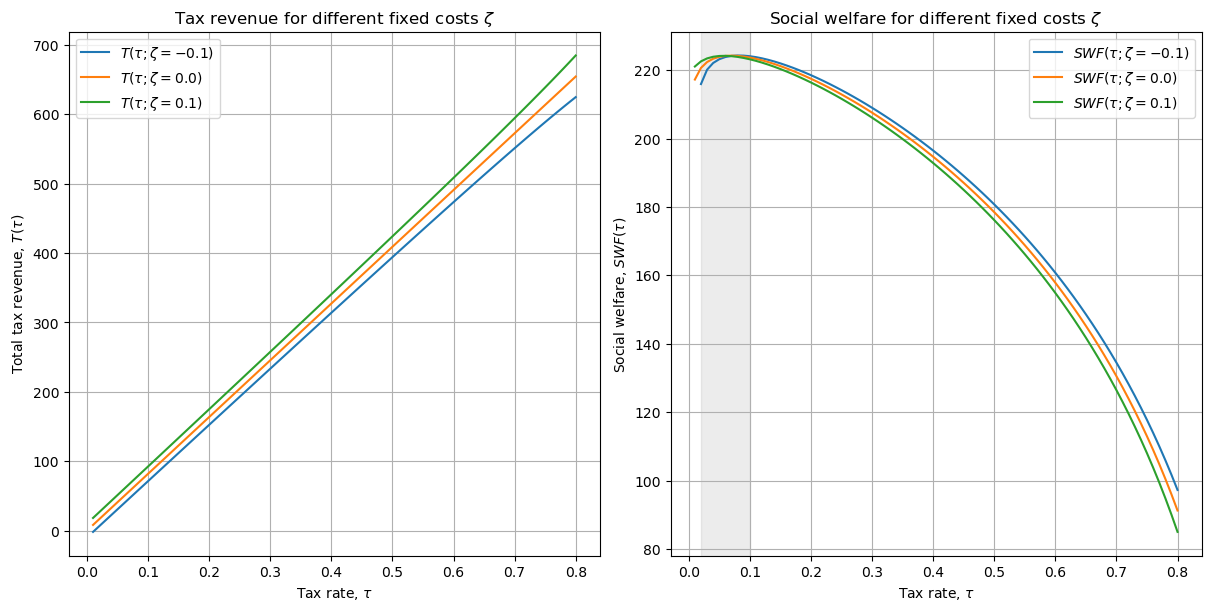

In [10]:
# 1. initiate plot
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), constrained_layout=True)

# left panel: Tax revenue
ax[0].set_xlabel(r'Tax rate, $\tau$')
ax[0].set_ylabel(r'Total tax revenue, $T(\tau)$')
ax[0].set_title('Tax revenue for different fixed costs $\\zeta$')
ax[0].grid(True)

# right panel: Social welfare
ax[1].set_xlabel(r'Tax rate, $\tau$')
ax[1].set_ylabel(r'Social welfare, $SWF(\tau)$')
ax[1].set_title('Social welfare for different fixed costs $\\zeta$')
ax[1].grid(True)

# 2. set up vectors
zeta_vec = [-0.1,0.0,0.1]
tau_vec = np.linspace(0.01, 0.8, 80)

# 3. plot using loop 
for zeta_val in zeta_vec:
    
    # 3.1 grids
    T_grid, SWF_grid = [], []
    
    for tau_val in tau_vec:
        
        # 3.2 set up model
        model = Government.GovernmentClass()
        sol = model.sol
        par = model.par
        
        # 3.3 get and store solutions
        T = model.tot_tax_rev(tau=tau_val, zeta=zeta_val)
        SWF = model.SWF(tau=tau_val, zeta=zeta_val)
        T_grid.append(T)
        SWF_grid.append(SWF)
        
    # 3.4 add lines to plot   
    ax[0].plot(tau_vec, T_grid,  label=fr'$T(\tau;\zeta={zeta_val})$')
    ax[1].plot(tau_vec, SWF_grid, label=fr'$SWF(\tau;\zeta={zeta_val})$')

# 4. add legends
ax[1].axvspan(0.02, 0.1, alpha=0.15, color='grey', edgecolor='none')

ax[0].legend()
ax[1].legend()

> **Partial Conclusion:** It looks like the social welfare function has a global optimum at $\tau\approx 0.05$ for the given parameters - approximate area marked in gray.
>
> Initially, I notice that it looks like optimization of the $SWF$ is a lot more dependent on the value of $\tau$ than of $\zeta$ as the different $\zeta$'s do not change the SWF-function's value.

### 2.2.1-2 Optimal taxation

Having defined $SWF$ as a function of $(\tau,\zeta)$ I run an optimization of the two parameters cocurrently. Though, first I have to define the endogenous bounds for $\zeta$ as specified in the assignment.

I confirm that I find a solution and that the initial value does not matter by drawing some random initial values around the optimum, given the constraints:

In [11]:
# 1. baseline optimum
model.max_SWF(verbose=False)

tau_star  = model.sol.tau_star
zeta_star = model.sol.zeta_star

# 2. compute zeta_maz
zeta_max = (1-sol.tau_star) * par.w*par.p_vec.min()*par.ell_max

# 3. draw for consistent results
np.random.seed(1015)

# 4. draw initial values and evaluate solutution
for it in range(5):
    
    # 4.1 draw
    tau0  = np.random.uniform(max(0.0, tau_star - 0.10),min(0.9999, tau_star + 0.10))
    zeta0 = np.random.uniform(zeta_star - 0.10, min(zeta_star + 0.10, zeta_max))

    # 4.2 solve
    res = model.max_SWF(verbose=False, x0=[tau0, zeta0])
    sol = model.sol

    # 4.3 print
    print(
        f"draw {it+1}: x0=[{tau0:.3f}, {zeta0:.3f}] -> "
        f"tau*={sol.tau_star:.4f}, zeta*={sol.zeta_star:.4f}, "
        f"SWF={sol.SWF_max:.4f}"
    )

draw 1: x0=[0.151, -0.517] -> tau*=0.1256, zeta*=-0.4447, SWF=224.3500
draw 2: x0=[0.149, -0.415] -> tau*=0.1256, zeta*=-0.4447, SWF=224.3500
draw 3: x0=[0.190, -0.371] -> tau*=0.1255, zeta*=-0.4445, SWF=224.3500
draw 4: x0=[0.184, -0.521] -> tau*=0.1256, zeta*=-0.4447, SWF=224.3500
draw 5: x0=[0.196, -0.448] -> tau*=0.1255, zeta*=-0.4441, SWF=224.3500


> **Partial conclusion:** The problem solves and is not dependent on the initial values as the random draw lead the same solution.
>
> That being said, the optimum for zeta must be flatter as the optimization here is less consistent in the later decimals.

### 2.2.3 3D plots of tax revenue and social welfare

Next I plot $T(\tau,\zeta)$ and $SWF(\tau,\zeta)$ for a list of value around $(\tau^\star,\zeta^\star)$ to display the functions in three dimensions, with the function value on the third axis:

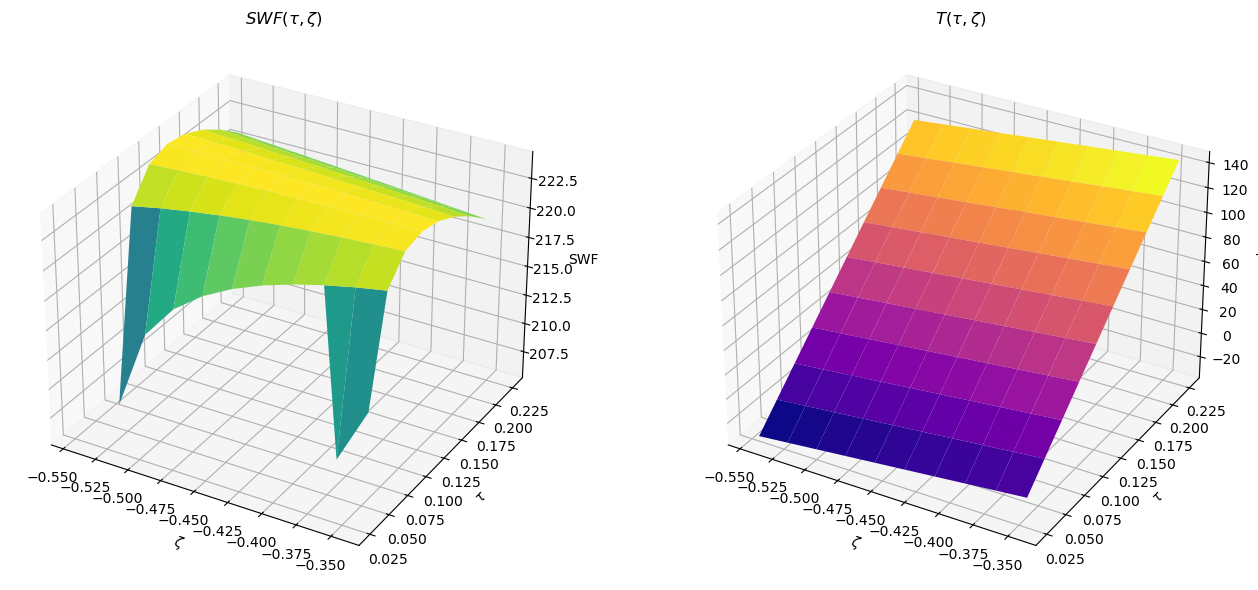

In [12]:
range_opt = 10

# 1. grids
zeta_grid = np.linspace(zeta_star -0.1, zeta_star +0.1, range_opt)
tau_grid = np.linspace(tau_star -0.1, tau_star +0.1, range_opt)
TAU, ZETA = np.meshgrid(tau_grid, zeta_grid)

SWF_vals = np.zeros_like(TAU)
T_vals   = np.zeros_like(TAU)

# 2. evaluate
for i in range(range_opt):
    for j in range(range_opt):
        SWF_vals[j, i] = model.SWF(tau=TAU[j, i], zeta=ZETA[j, i])
        T_vals[j, i]   = model.tot_tax_rev(tau=TAU[j, i], zeta=ZETA[j, i])
        
# 3. plot
fig = plt.figure(figsize=(14, 6))

# 3.1 Plot SWF
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(ZETA, TAU, SWF_vals, cmap='viridis', edgecolor='none')
ax1.set_ylabel(r'$\tau$')
ax1.set_xlabel(r'$\zeta$')
ax1.set_zlabel('SWF')
ax1.set_title(r'$SWF(\tau,\zeta)$')

# 3.2 plot Tax rev
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(ZETA, TAU, T_vals, cmap='plasma', edgecolor='none')
ax2.set_ylabel(r'$\tau$')
ax2.set_xlabel(r'$\zeta$')
ax2.set_zlabel('T')
ax2.set_title(r'$T(\tau,\zeta)$')

plt.tight_layout()
plt.show()

> **Partial conclusion:** In the right plot, I see that the tax revenue is increasing weakly in $\zeta$ and strongly in $\tau$. I.e. the taxation amount is more important for the tax revenue than the transfers.
>
> The same is evident in the left plot of the $SWF$, that has a clear optimum in $\tau$, but a way less strict in $\zeta$ as we also saw when evaluating the solution set for different initial values.

### 2.2.4 The Lorenz-curve

The assignment has defined consumption of a given individual to:

$$
    c_i = (1-\tau) w p_i\ell_i-\zeta
$$

from which it is easy to see, that it depends on the individual characteristics $(p_i,\ell_i)$ and, of cause, also $\tau$ and $\zeta$. Thus, to get the Lorenz-curve for consumption I:

1. Sort individuals by their level of consumption.
2. Compute the share of total consumption for each percentile of the consumption distribution.

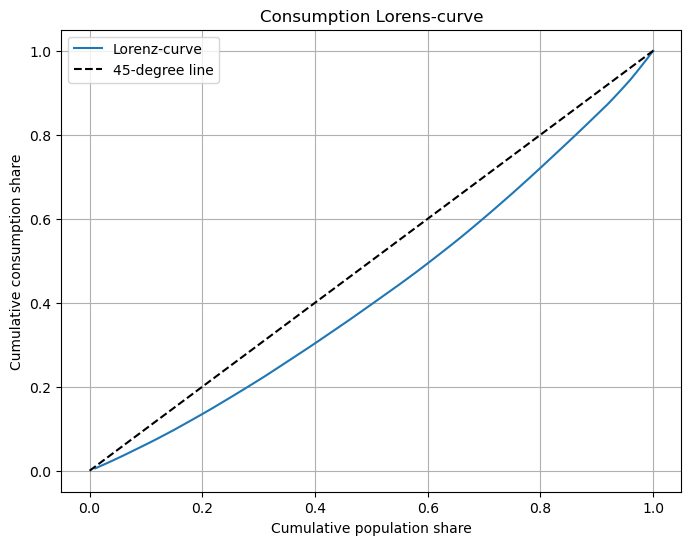

In [13]:
# 1. compute consumption per individual
c_vec = (1-sol.tau_star) * par.w * par.p_vec * sol.ell_vec - sol.zeta_star

# 2. compute the cumulative consumption vector
sorted_cons = np.sort(c_vec)
cum_cons = np.cumsum(sorted_cons) / np.sum(sorted_cons)

# 3. compute percentiles of the population
N = len(sorted_cons)
cum_pop = np.arange(1, N+1) / N

# 3. plot
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(cum_pop, cum_cons, label='Lorenz-curve')
ax.plot([0,1], [0,1], 'k--', label='45-degree line')
ax.set_xlabel('Cumulative population share')
ax.set_ylabel('Cumulative consumption share')
ax.set_title('Consumption Lorens-curve')
ax.legend()
ax.grid(True)

>**Partial conclusion:** As is often the case, I see the Lorenz-curve below the 45-degree line that marks complete equality, i.e., this simulated economy has some inequality, with the richer, those with higher productitivy, $p_i$, consuming more than an equal share.

## 3. Top tax

### 3.1-3 Plots

Next, I consider the proposed top tax system. First, I plot $U(p_i,c_i,\ell_i)$, $\underline{\varphi}(p_i,c_i,\ell_i)$ and $\bar{\varphi}(p_i,c_i,\ell_i)$ with $c_i$ substituted through $y_i$, making it a problem of one variable, assuming $p_i=1$.

To perform this excercise I build the functions `gross_income` (pre-tax), `income_top` (post tax for top-tax earners), `utility_top`, `FOC_above` (below is simply the earlier defined `FOC`) and `solve_top_tax_root` in `labourer_class`.

`solve_top_tax_root` maks the optimum, solving it by a root-finder; thus, already, building the framework for answering 3.1.5:

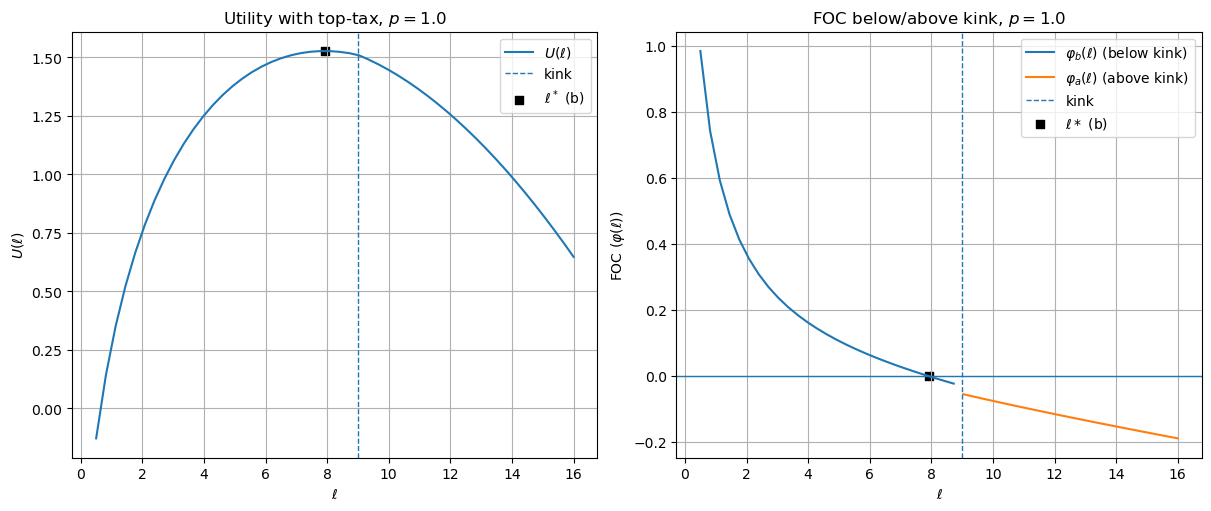

In [14]:
# 1. import classes
labour = Laborer.labourer_class()
sol_l = labour.sol
par_l = labour.par
        
gov = Government.GovernmentClass()
sol_g = gov.sol
par_g = gov.par

# 2. get pars
gov.max_SWF(verbose=False)
par_l.tau   = sol_g.tau_star
par_l.zeta  = sol_g.zeta_star
par_l.p     = 1.0
ell_k       = par_l.kappa / (par_l.w * par_l.p)
U_kink      = labour.utility_top(ell_k)

# 3. define ell-intervals
ell_full_grid = np.linspace(0.5, par_l.ell_max, 50)
ell_b_grid    = ell_full_grid[ell_full_grid < ell_k] 
ell_a_grid    = ell_full_grid[ell_full_grid >= ell_k]   

# 7. compute utility over the full interval
U_full = np.array([labour.utility_top(ell) for ell in ell_full_grid])

# 8. compute FOCs on each side of kink
phi_b = np.array([labour.FOC(ell) for ell in ell_b_grid])
phi_a = np.array([labour.FOC_above(ell) for ell in ell_a_grid])

# 9. solution for single scatter
ell_star, type_star, U_star, FOC_at_root = labour.solve_top_tax_root(verbose=False)

# 10. plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# 10.1 utility
ax = axes[0]
ax.plot(ell_full_grid, U_full, label=r'$U(\ell)$')
ax.axvline(ell_k, linestyle='--', linewidth=1, label='kink')
ax.scatter(ell_star, U_star, marker='s', color='black', label=rf'$\ell^*$ ({type_star})')
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$U(\ell)$')
ax.set_title(r'Utility with top-tax, $p=1.0$')
ax.grid(True)
ax.legend()

# 10.2 FOCs
ax = axes[1]
ax.axhline(0.0, linestyle='-', linewidth=1)
ax.plot(ell_b_grid, phi_b, label=r'$\varphi_b(\ell)$ (below kink)')
ax.plot(ell_a_grid, phi_a, label=r'$\varphi_a(\ell)$ (above kink)')
ax.axvline(ell_k, linestyle='--', linewidth=1, label='kink')
ax.scatter(ell_star, FOC_at_root, marker='s',color='black', label=rf'$\ell*$ ({type_star})')
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'FOC $(\varphi(\ell))$')
ax.set_title(r'FOC below/above kink, $p=1.0$')
ax.grid(True)
ax.legend()

plt.show()

> **Partial conclusion:** From the left plot I see that utility is maximized at an hours choice of about $8$ which lies just below the kink at about $9$. So the worker’s optimum is in region `b` (below the top-tax threshold); they choose not to enter the top bracket, if their productivity is $p_i=1$.
> It is likely that higher productivity individuals might work into the top-tax bracket.
> 
> This is confirmed by the FOC, which crosses zero before $\ell_k$, making all $\ell_a<0$.

### 3.1.4-6 Solve by numerical solver

Having already build the root-finder (FOC) approach, I reuse my established framework, but change the solver itself, by making it based on the utility function rather than the FOC. This also makes it possible for me to drop the step wise framework for a simpler one.

Having done this, I can the compute the solution through both methods:

In [15]:
# 1. solve numerically
t0 = time.perf_counter()
labour.solve_top_tax_num(verbose=True)  
t1 = time.perf_counter()
elapsed_num = t1 - t0 

# 2. solve via root
t0 = time.perf_counter()
labour.solve_top_tax_root(verbose=True)  
t1 = time.perf_counter()
elapsed_root = t1 - t0


=== NUMERICAL solution for labour supply with top-tax ===

Price (p)          : 1.000
Wage (w)           : 1.000
Tax rate (tau)     : 0.126
Fixed cost (zeta)  : -0.445
Top tax (omega)    : 0.200
Kink (kappa)       : 9.000
ell kink (ell_k)   : 9.000
----------------------------------------------------
Region type        : b
Optimal hours ell* :  7.9147
Utility U(ell*)    :  1.5270


=== ROOT solution for labour supply with top-tax ===

Price (p)          : 1.000
Wage (w)           : 1.000
Tax rate (tau)     : 0.126
Transfer (zeta)    : -0.445
Top tax (omega)    : 0.200
Kink (kappa)       : 9.000
ell kink (ell_k)   : 9.000
----------------------------------------------------
Region type        : b
Optimal hours ell* :  7.9147
Utility U(ell*)    :  1.5270



In [16]:
# 3. print timing
print(f"Elapsed time (numerical optimization): {elapsed_num*1000:.3f} ms ({elapsed_num:.3f} seconds.)")
print(f"Elapsed time (root finder): {elapsed_root*1000:.3f} ms ({elapsed_root:.3f} seconds.)")

Elapsed time (numerical optimization): 1.438 ms (0.001 seconds.)
Elapsed time (root finder): 0.584 ms (0.001 seconds.)


> **Partial conclusion:** They yield the same result as they are solve the same problem merely through different approaches. 
>
> Once again, there is a remarkable difference in their elapsed times with the root-finder being nearly twich as fast. By the levels of the solving-time are, currently, so low that the difference is not felt.

### 3.1.7 Single figure

Like in excercise one, I answer this sub-question by plotting utility and FOCs for three values of $p_i$ in the same plots, laying the foundation for a visual, comparative analysis:

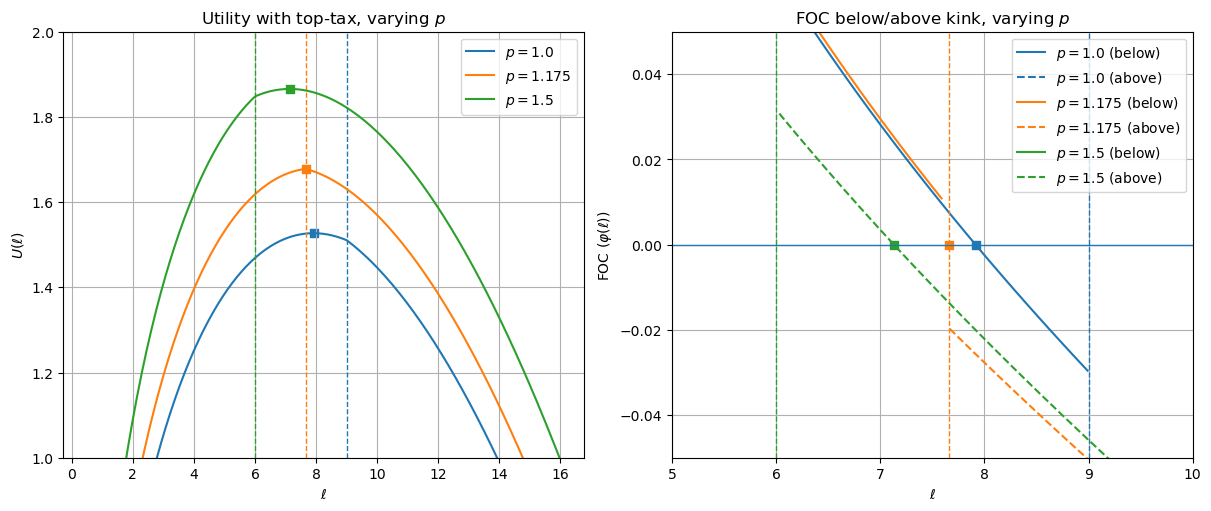

In [17]:
# 0. set up figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# 0.1 utility
ax0 = axes[0]
ax0.set_xlabel(r'$\ell$')
ax0.set_ylabel(r'$U(\ell)$')
ax0.set_title(r'Utility with top-tax, varying $p$')
ax0.grid(True)
ax0.set_ylim(1,2)

# 0.2 FOCs
ax1 = axes[1]
ax1.axhline(0.0, linestyle='-', linewidth=1)
ax1.set_xlabel(r'$\ell$')
ax1.set_ylabel(r'FOC $(\varphi(\ell))$')
ax1.set_title(r'FOC below/above kink, varying $p$')
ax1.grid(True)
ax1.set_ylim(-0.05, 0.05)
ax1.set_xlim(5, 10)

# 0.3 set colours + create classes once
p_list     = [1.0, 1.175, 1.5]
color_list = ['C0', 'C1', 'C2']

labour = Laborer.labourer_class()
sol_l = labour.sol
par_l = labour.par

gov = Government.GovernmentClass()
sol_g = gov.sol
par_g = gov.par

gov.max_SWF(verbose=False)
par_l.tau   = sol_g.tau_star
par_l.zeta  = sol_g.zeta_star
par_l.kappa = par_g.kappa
par_l.omega = par_g.omega

# 1. run for several p
for p, color in zip(p_list, color_list):

    # 1. set p and kink stuff
    par_l.p = p
    ell_k   = par_l.kappa / (par_l.w * par_l.p)
    U_kink  = labour.utility_top(ell_k)

    # 2. define ell-intervals
    ell_full_grid = np.linspace(0.5, par_l.ell_max, 200)
    ell_b_grid    = ell_full_grid[ell_full_grid < ell_k]
    ell_a_grid    = ell_full_grid[ell_full_grid >= ell_k]

    # 3. utility & FOCs
    U_full = np.array([labour.utility_top(ell) for ell in ell_full_grid])
    phi_b  = np.array([labour.FOC(ell)        for ell in ell_b_grid])
    phi_a  = np.array([labour.FOC_above(ell)  for ell in ell_a_grid])

    # 4. solution
    ell_star, type_star, U_star, FOC_at_root = labour.solve_top_tax_root(verbose=False)

    # 5. case-dependent elements: utility
    ax0.plot(ell_full_grid, U_full, label=rf'$p={p}$', color=color)
    ax0.axvline(ell_k, linestyle='--', linewidth=1, color=color)
    ax0.scatter(ell_star, U_star, marker='s', color=color)

    # 6. ...: FOCs
    ax1.plot(ell_b_grid, phi_b,           color=color, label=rf'$p={p}$ (below)')
    ax1.plot(ell_a_grid, phi_a, linestyle='--', color=color, label=rf'$p={p}$ (above)')
    ax1.axvline(ell_k, linestyle='--', linewidth=1, color=color)
    ax1.scatter(ell_star, 0.0, marker='s', color=color)

ax0.legend()
ax1.legend()

Compute concrete solutions:

In [18]:
# 1. loop
for p in p_list: 
    
    # 2. specify p and solve
    par_l.p = p
    print(f'=== p={p}')
    
    labour.solve_top_tax_root(verbose=True)  

=== p=1.0

=== ROOT solution for labour supply with top-tax ===

Price (p)          : 1.000
Wage (w)           : 1.000
Tax rate (tau)     : 0.126
Transfer (zeta)    : -0.445
Top tax (omega)    : 0.200
Kink (kappa)       : 9.000
ell kink (ell_k)   : 9.000
----------------------------------------------------
Region type        : b
Optimal hours ell* :  7.9147
Utility U(ell*)    :  1.5270

=== p=1.175

=== ROOT solution for labour supply with top-tax ===

Price (p)          : 1.175
Wage (w)           : 1.000
Tax rate (tau)     : 0.126
Transfer (zeta)    : -0.445
Top tax (omega)    : 0.200
Kink (kappa)       : 9.000
ell kink (ell_k)   : 7.660
----------------------------------------------------
Region type        : k
Optimal hours ell* :  7.6596
Utility U(ell*)    :  1.6780

=== p=1.5

=== ROOT solution for labour supply with top-tax ===

Price (p)          : 1.500
Wage (w)           : 1.000
Tax rate (tau)     : 0.126
Transfer (zeta)    : -0.445
Top tax (omega)    : 0.200
Kink (kappa)     

> **Partial conclusion:** As productivity increases, ceteris paribus, the FOC moves to the left, i.e., towards fewer working hours.
>
> The increased top-tax rate will have increased this effect as it reduces the disposible marginal income of working an hour more, when one is within the top-tax zone.
>
> That being said, I see that the highest productivity individuals still enjoy work enough so that they end up in the top tax group.

### 3.2.1 Labour supply function

To investigate further the effect of the top tax on individuals across productivity levels, I plot the labor supply for different produvtivity levels:

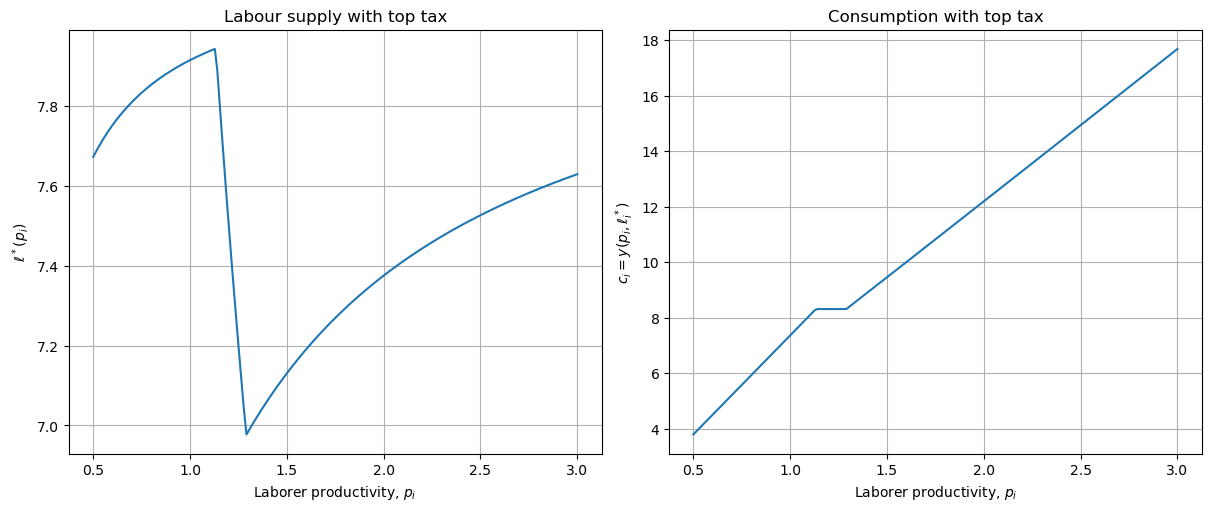

In [19]:
# 0. policy from government
gov   = Government.GovernmentClass()
sol_g = gov.sol
par_g = gov.par

gov.max_SWF(verbose=False) # find tau*, zeta*

# 1. worker model with those tax params
labour = Laborer.labourer_class()
sol_l  = labour.sol
par_l  = labour.par

par_l.tau   = sol_g.tau_star
par_l.zeta  = sol_g.zeta_star

# 2. define p-grid
p_grid = np.linspace(0.5, 3, 200)
ell_sol_grid = []

# 3. loop over p
for p in p_grid:
    par_l.p = p
    ell_star, type_star = labour.solve_top_tax_num(verbose=False)
    ell_sol_grid.append(ell_star)

# 4. implied consumption under top tax
c_sol_grid = []
for p, ell_star in zip(p_grid, ell_sol_grid):
    labour.par.p = p
    c_sol_grid.append(labour.income_top(ell_star))

fig, ax = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

ax[0].plot(p_grid, ell_sol_grid)
ax[0].set_xlabel(r'Laborer productivity, $p_i$')
ax[0].set_ylabel(r'$\ell^*(p_i)$')
ax[0].set_title('Labour supply with top tax')

ax[1].plot(p_grid, c_sol_grid)
ax[1].set_xlabel(r'Laborer productivity, $p_i$')
ax[1].set_ylabel(r'$c_i = y(p_i,\ell_i^*)$')
ax[1].set_title('Consumption with top tax')

ax[0].grid(True); ax[1].grid(True)

> **Partial conclusion:** An intuitive pattern occurs: For people with adequately low productivty, there is no effect of the top tax as they, at their optimal amount of working hours, do not make enough to be hit by the extra tax.
>
> But then, the income group just around the top-tax-kink reduce their working hours substically, $>1.5$ hours, as they now will get the same disposible income at this lower number of working hour, due to the high tax if the go beyond the kink.
>
> To the right, at the top of the productivity distribution, it is again optimal for the agents to work a  hours even as the top tax take a proportinally larger abount of their labour income.
>
> In sum, the agents that are just on the boundery of the taxation are hit hardest

### 3.2.2 Composition of the labor force

Next I computhe the shares of each type of worker over the defined productivity-grid, I compute the three shares through my defined variable `t_star` that specifies exactly the type of each individual:

In [20]:
types = []

# 1. reuse grid:
for p in p_grid:
    
    # 1.1 run root-finder with changes
    model = Laborer.labourer_class()
    par = model.par
    par.p = p
    
    # 1.2 get type_star
    ell_star, type_star, U_star, FOC_at_root = model.solve_top_tax_root(verbose=False)
    types.append(type_star)

# 3. count
type_counts = Counter(types)
N = len(types)

# 4. pretty print
print("\n=== Labour-supply types across p-grid ===\n")
for t in ['b', 'k', 'a']:   
    n = type_counts.get(t, 0)
    share = n / N if N > 0 else 0
    print(f"type {t}: {n:3d}  ({share:5.1%})")


=== Labour-supply types across p-grid ===

type b:  47  (23.5%)
type k:  26  (13.0%)
type a: 127  (63.5%)


> *Partial conclusion:** Over the specified productivity grid, the distribution of the three types is quite equal, which is consistent with the figure that first showed an unaffected group, $b$, a heaviy affected, $k$ and then the very high productivity group, $a$, whose reponse was inbetween the other two.

### 3.3.1 Public good

Next, I compare the value of the $SWF$ in two scenarios: with- and without the top tax rate. I create the additional functions `tot_tax_rev_top_tax` and `SWF_top` for the top-tax scenario and reuse the previous framework for the reference:

In [21]:
# 1. initiate
gov = Government.GovernmentClass()
gov.max_SWF(verbose=False)    
par = gov.par
tau_star  = gov.sol.tau_star
zeta_star = gov.sol.zeta_star   

# 2. compute SWF
swf_base = gov.SWF(tau=tau_star, zeta=zeta_star)    
swf_top = gov.SWF_top(tau=tau_star, zeta=zeta_star)
diff_swf = swf_top - swf_base

# 3. get tax rev
T_base = gov.tot_tax_rev(tau=tau_star, zeta=zeta_star)
T_top, ell_vec = gov.tot_tax_rev_top_tax(tau=tau_star, zeta=zeta_star)

# 3. print
print("\n=== Comparison: SWF with and without top tax ===\n")
print(f"Tax rate (tau)             : {tau_star:.4f}")
print(f"Fixed cost (zeta)          : {zeta_star:.4f}")
print(f"Top tax rate (omega)       : {par.omega:.4f}")
print(f"Top tax threshold (kappa)  : {par.kappa:.4f}")
print("-----------------------------------------------")
print(f"Tax revenue without top    : {T_base:.6f}")
print(f"Tax revenue with top tax    : {T_top:.6f}")
print("-----------------------------------------------")
print(f"SWF without top tax        : {swf_base:.6f}")
print(f"SWF with top tax           : {swf_top:.6f}")
print(f"Difference (top - base)    : {diff_swf:.6f}\n")


=== Comparison: SWF with and without top tax ===

Tax rate (tau)             : 0.1256
Fixed cost (zeta)          : -0.4447
Top tax rate (omega)       : 0.2000
Top tax threshold (kappa)  : 9.0000
-----------------------------------------------
Tax revenue without top    : 55.081327
Tax revenue with top tax    : 55.456454
-----------------------------------------------
SWF without top tax        : 224.349993
SWF with top tax           : 223.733451
Difference (top - base)    : -0.616541



> **Partial conclusion:** Initially, the top tax has decreased the social welfare (by the chosen SWF-function), even as the tax revenue has increased. 
>
> The explanation must be that the increase in the tax revenue is offset by a larger fall in the aggregated worker utility.

### 3.3.2 Lorenz curve

Further, I recompile also the Lorenz-curve of consumption. I base this on the reference scenario and add the new curve for the top tax scenario on top:

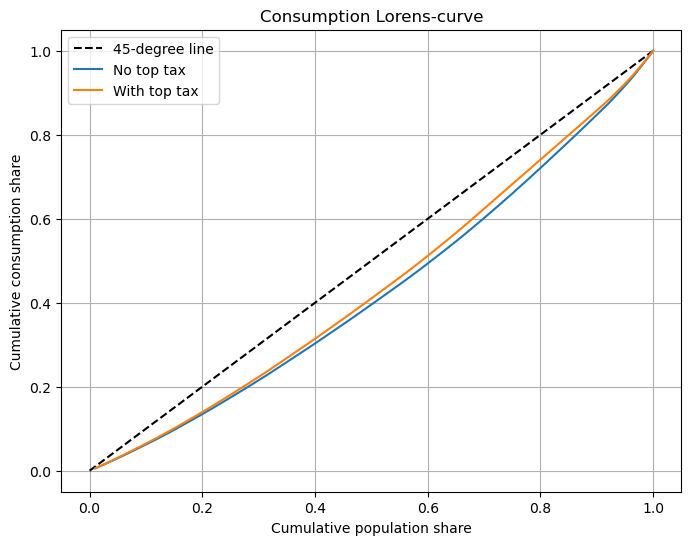

In [22]:
# 1. initiate figure
fig, ax = plt.subplots(figsize=(8,6))
ax.plot([0,1], [0,1], 'k--', label='45-degree line')
ax.set_xlabel('Cumulative population share')
ax.set_ylabel('Cumulative consumption share')
ax.set_title('Consumption Lorens-curve')
ax.grid(True)

# 2. compute case specific consumption
sol = gov.sol
par = gov.par
N = par.N

# 2.1 no top tax
c_vec_nt = (1-tau_star) * par.w * par.p_vec * sol.ell_vec - zeta_star

sc_nt = np.sort(c_vec_nt)
cum_cons_nt = np.cumsum(sc_nt) / np.sum(sc_nt)
cum_pop_nt = np.arange(1, N+1) / N

# 2.2 with top tax
c_vec_wt = (1-tau_star) * par.w * par.p_vec * sol.ell_vec_top_tax - zeta_star

sc_wt = np.sort(c_vec_wt)
cum_cons_wt = np.cumsum(sc_wt) / np.sum(sc_wt)
cum_pop_wt = np.arange(1, N+1) / N

# 3. add to plot
ax.plot(cum_pop_nt, cum_cons_nt, label='No top tax')
ax.plot(cum_pop_wt, cum_cons_wt, label='With top tax')

ax.legend()

> **Partial conclusion:** The top tax has visible redistributional effects; it decreses the inequality, visible by the Lorenz-curve closer to the 45-degree line.
>
> This is due to the fact that the highest earners, now pay a larger proportion (i.e. both absolut and relatively) more tax. In the current set-up, this is redistributed equaly among individuals; the mechanism would be stronger if the redistribution was skewed towards to poorer.

### 3.3.3 Increasing social welfare through top taxation

I started by solving this problem for  $(\tau,\zeta)$ and found that any top tax rates could not yield higher social welfare. But this was also adapting $(\omega,\kappa)$ to an already optimized system without top taxation.

Thus, to let all the effects interplay properly, I solved numerically over $(\tau,\zeta,\omega,\kappa)$. This numerical solver is build on top of the rest of `GovernmentClass`:

In [23]:
gov = Government.GovernmentClass()

gov.max_SWF(verbose=False)
res = gov.max_policies(verbose=True)


=== Numerical solution for optimal tax system (tau, zeta, omega, kappa) ===

Optimal linear tax (tau*)     : 0.0679
Optimal transfer (zeta*)      : 0.0051
Optimal top tax (omega*)      : 0.0594
Optimal threshold (kappa*)    : 10.6742
------------------------------------------------
SWF without top tax           : 224.233207
Max SWF with top tax          : 224.250075
Gain (top - base)             : 0.016869
Converged?                    : True



> **Partial conclusion:** Optimizing the whole vector $(\tau,\zeta,\omega,\kappa)$, I am able to compute a higher value of social welfare with top tax system in place.

## 4 Model extention

For my model extention I perform a simple experiment, looking at different normal-distributions for $p_i$ by changing $\sigma_p^2$:

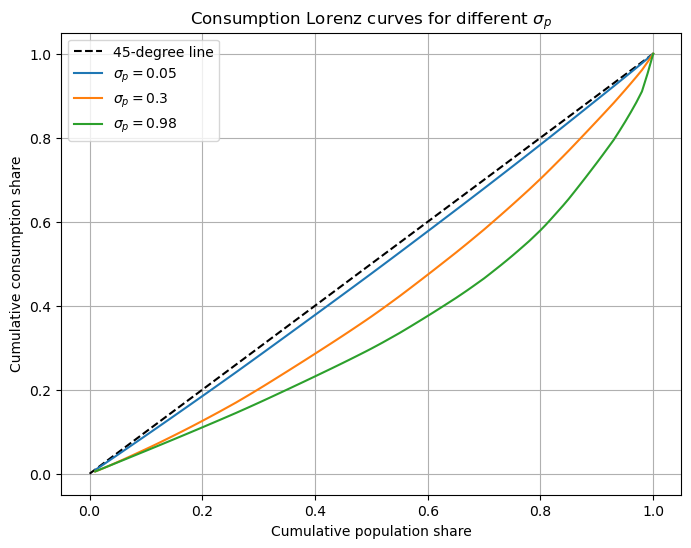

In [24]:
# 0. initiate class, solve for tau*, zeta*
gov = Government.GovernmentClass()
gov.max_SWF(verbose=False)
par = gov.par
sol = gov.sol
tau_star  = sol.tau_star

# 1. helper: Lorenz curve from a consumption vector
def lorenz(c_vec):
    sc = np.sort(c_vec)
    cum_cons = np.cumsum(sc) / np.sum(sc)
    cum_pop  = np.arange(1, len(sc)+1) / len(sc)
    return cum_pop, cum_cons

# 2. sigmas to try
sigma_list = [0.05, 0.3, 0.98]

# 3. figure
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', label='45-degree line')
ax.set_xlabel('Cumulative population share')
ax.set_ylabel('Cumulative consumption share')
ax.set_title('Consumption Lorenz curves for different $\sigma_p$')
ax.grid(True)

# 3. loope to plot
for sigma_p in sigma_list:
    gov = Government.GovernmentClass()
    par = gov.par
    sol = gov.sol

    # 3.1 change dispersion and redraw productivities
    par.sigma_p = sigma_p
    gov.p_vec   = gov.draw_productivities()
    par.p_vec   = gov.p_vec

    # 3.2 find optimal (tau*, zeta*)
    gov.max_SWF(verbose=False)
    tau_star  = sol.tau_star
    zeta_star = sol.zeta_star

    # 3.3 compute micro outcomes at optimum (no top tax case)
    T_opt, ell_vec = gov.tot_tax_rev(return_micro=True,
                                     tau=tau_star, zeta=zeta_star)

    # 3.4 consumption vector at optimum
    c_vec = (1 - tau_star) * par.w * par.p_vec * ell_vec - zeta_star

    # 3.5 Lorenz curve
    cum_pop, cum_cons = lorenz(c_vec)
    ax.plot(cum_pop, cum_cons, label=rf'$\sigma_p = {sigma_p}$')

ax.legend()
plt.show()

> **Partial conclusion:** The inequality is clearly increasing in the degree of heterogenity. When the spread of $p_i$ increses so does the inequality.

### Main conclusion

- I set up a simple labour–supply model with log utility in consumption and a convex disutility of work, and solved the worker problem both by direct numerical maximization and by a robust root-finder on the FOC.
- The implementation respects the feasibility constraint $c(\ell) > 0$, and the solver correctly delivers either interior or corner solutions depending on parameters like $\tau, \zeta$ and $\epsilon$, which I illustrate in the figures.
- On the government side, I compute total tax revenue and a social welfare index that combines aggregate revenue with individual utilities, and use constrained optimization to determine optimal $(\tau, \zeta)$.
- I then extend the model with a kinked top-tax schedule $(\omega, \kappa)$, solve the piecewise worker problem, and classify workers into the regions $b$, $k$ and $a$ based on their optimal hours.
- Finally, I compare the baseline and the top-tax regime and show that a suitably chosen top tax can raise social welfare while remaining consistent with individual optimization and the government’s budget constraint.
